# Байесовский подход в анализе данных
## Задание 7

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


**Баллы за задание:**

* Задача 1 — 140 баллов.
* Задача 2 — 60 баллов.
* Задача 3 — 40 баллов.

-----------

In [1]:
# Bot check

# HW_ID: ds_bayes7
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import torch
import torch.nn as nn

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(palette='Set2', font_scale=1.3)

from IPython.display import clear_output

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. https://chat.qwen.ai/s/18d09653-bebc-4e70-9e4a-8382d44a7221?fev=0.0.230
    - Проверка кода на синтаксические и логические ошибки и описки.
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована
...

In [3]:
import os

import numpy as np
import torch
import torchvision.datasets as dset
import torch.nn as nn
import torchvision.transforms as transforms

import pyro
import pyro.distributions as dist
import pyro.contrib.examples.util  # patches torchvision
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from sklearn.decomposition import PCA

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

import seaborn as sns
sns.set(palette='Set2', font_scale=1.3)

from IPython.display import clear_output

from scipy.special import expit
from umap.umap_ import UMAP 

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [4]:
pyro.enable_validation(True)
pyro.set_rng_seed(0)

# отключим валидацию аргументов распределений
pyro.distributions.enable_validation(False)
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
USE_CUDA

True

---
### Задача 1.

<font color="red"><b>Перед выполнением задачи прочитайте советы и указания ниже.</b></font>

Эта задача призвана проиллюстрировать на простом примере принцип работы вариационного автоэнкодера (VAE) в сравнении с методом главных компонент (PCA) и простым автоэнкодером (AE) на трех наборах данных.

Реализуйте стандартную модель VAE, в котором данные как на выходе энкодера, так и на выходе декодера описываются нормальным распределением. Все слои нейронных сетей — полносвязные. Реализуйте также аналогичную модель AE.


*Указания.*
* Обязательно посмотрите код с занятия. Обращайте внимание на размерности распределений.
* Несмотря на небольшое количество данных, обучение по случайным мини-батчам может работать лучше.
* Обучайте VAE аккуратно. На таких данных он может достаточно долго пытаться приблизить данные константным средним и большой дисперсией. Спустя большое количество итераций он все же нащупает правильную зависимость. Сотни тысяч итераций по мини-батчам — нормально.
* Обучение может и не сойтись к желаемой зависимости из-за неправильного выбора гиперпараметров сети и шага обучения. Посмотрите на выбор гиперпараметров в примерах с занятий.
* Не стоит брать слишком глубокие сети для достаточно простых данных. Но и слишком маленькие тоже не стоит, 2-4 слоя должно хватать.
* Обратите внимание на функции активации. Особенно для компонент, отвечающих за дисперсию. Возможно, потребуется перебрать несколько вариантов. Не забудьте, что дисперсия не может быть отрицательной :)
* В некоторых случаях может помочь использование или неиспользование слоев Dropout и BatchNorm.
* **Если у вас получаются плохо интерпретируемые результаты, скорее всего модель обучилась неправильно, или гиперпараметры выбраны неудачно.** Перечитайте еще раз все рекомендации, перепроверьте свое решение. Если не помогло, задайте вопрос в чате.

In [5]:
def callback(train_elbo, test_elbo, test_epoch_num, epoch, title="ELBO"):
    '''
    Отрисовка текущего статуса обучения.    
    '''
    
    # Отложенная очистка экрана
    clear_output(wait=True)
    
    # Объявление фигуры и сетки
    plt.figure(figsize=(10, 4), constrained_layout=False)
    plt.plot(range(1, len(train_elbo)+1), train_elbo, lw=2, color='#00CC66', label='train')
    plt.plot(test_epoch_num, test_elbo, lw=2, color='#FF3300', label='test')
    plt.legend()
    plt.xlabel('Номер эпохи')
    plt.title(f'Эпоха {epoch}. {title}')
    plt.show()

def visualize_or_not(it, n_iter):
    """
    Функция, которая определяет, визуализировать ли результат данной итерации.

    * it -- номер текущей итерации
    * n_iter -- количество итераций чередования E и M шагов
    """

    return (
        (it < 10)
        or ((it % 10 == 0) and (it < 100))
        or ((it % 100 == 0) and (it < 1000))
        or (it % 1000 == 0)
    )

### **VAE**

Возьмем энкодер и декодер с занятия, упростив их до 3 слоев.

In [6]:
class Encoder(nn.Module):

    def __init__(self, y_dim, p=0):
        super(Encoder, self).__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.Dropout2d(p=p),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Dropout2d(p=p),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Flatten(),
            nn.Dropout(p=p),
        )

        self.fc_output_loc = nn.Linear(64 * 7 * 7, y_dim)
        self.fc_output_scale = nn.Linear(64 * 7 * 7, y_dim)

    def forward(self, x):
        hidden = self.layers(x)
        y_loc = self.fc_output_loc(hidden)
        y_scale = torch.exp(self.fc_output_scale(hidden))
        return y_loc, y_scale


class Decoder(nn.Module):
    def __init__(self, y_dim, p=0):
        super(Decoder, self).__init__()

        self.first_layer = nn.Linear(y_dim, 64 * 7 * 7)

        self.layers = nn.Sequential(
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Dropout(p=p),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.Upsample(size=(14, 14)),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Dropout2d(p=p),
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.Upsample(size=(28, 28)),
            nn.LeakyReLU(),
        )

        self.mean_head = nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1)
        self.logvar_head = nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = self.first_layer(x)
        x = x.view(-1, 64, 7, 7)
        h = self.layers(x)

        mean = torch.sigmoid(self.mean_head(h))
        logvar = self.logvar_head(h)
        scale = torch.exp(0.5 * logvar)

        return mean, scale

In [7]:
# class Decoder(nn.Module):
#     ''' Реализация модели сверточного декодера. '''
    
#     def __init__(self, y_dim, p=0.1):
#         '''
#         y_dim -- размерность скрытого пространства
#         p -- параметр dropout
#         '''
        
#         super(Decoder, self).__init__()
        
#         # Первый несверточный слой вынесем отдельно
#         self.first_layer = nn.Linear(in_features=y_dim, out_features=64*7*7)

#         self.layers = nn.Sequential(
#             nn.BatchNorm2d(num_features=64),
#             nn.LeakyReLU(),
#             nn.Dropout(p=p),
#             nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
#             nn.Upsample(size=(14, 14)),  # увеличиваем размер картинки
#             nn.BatchNorm2d(num_features=64),
#             nn.LeakyReLU(),
#             nn.Dropout2d(p=p),
#             nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
#             nn.Upsample(size=(28, 28)),  # увеличиваем размер картинки
#             nn.BatchNorm2d(num_features=64),
#             nn.LeakyReLU(),
#             nn.Dropout2d(p=p),
#             nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(num_features=64),
#             nn.LeakyReLU(),
#             nn.Dropout2d(p=p),
#         )

#         self.mean_head = nn.Conv2d(in_channels=64, out_channels=1, kernel_size=3, stride=1, padding=1)
#         self.logvar_head = nn.Conv2d(in_channels=64, out_channels=1, kernel_size=3, stride=1, padding=1)

    
#     def forward(self, x):
#         x = self.first_layer(x)
#         x = x.view((-1, 64, 7, 7))
#         h = self.layers(x)

#         mean = torch.sigmoid(self.mean_head(h))
#         logvar = self.logvar_head(h)
#         scale = torch.exp(0.5 * logvar)

#         return mean, scale
    
# class Encoder(nn.Module):
#     ''' Реализация модели сверточного энкодера. '''
    
#     def __init__(self, y_dim, p=0.1):
#         '''
#         y_dim -- размерность скрытого пространства
#         p -- параметр dropout
#         '''
        
#         super(Encoder, self).__init__()

#         self.layers = nn.Sequential(
#             nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(num_features=64),
#             nn.LeakyReLU(),
#             nn.Dropout2d(p=p),
#             nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm2d(num_features=64),
#             nn.LeakyReLU(),
#             nn.Dropout2d(p=p),
#             nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
#             nn.MaxPool2d(kernel_size=2),
#             nn.BatchNorm2d(num_features=64),
#             nn.LeakyReLU(),
#             nn.Dropout2d(p=p),
#             nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(num_features=64),
#             nn.LeakyReLU(),
#             nn.Flatten(),  # растягиваем тензор в вектор
#             nn.Dropout(p=p)
#         )

#         # Полносвязные слои, отвечающие за среднее и дисперсию
#         # точки в скрытом пространстве
#         self.fc_output_loc = nn.Linear(in_features=3136, out_features=y_dim)
#         self.fc_output_scale = nn.Linear(in_features=3136, out_features=y_dim)

#     def forward(self, x):
#         hidden = self.layers(x)

#         # Считаем параметры распределения
#         y_loc = self.fc_output_loc(hidden)
#         y_scale = torch.exp(self.fc_output_scale(hidden))
#         return y_loc, y_scale

In [8]:
class VAE(nn.Module):
    """Реализация модели сверточного вариационного автоэнкодера."""

    def __init__(self, y_dim=2, p=0.2, use_cuda=False):
        """
        y_dim -- размерность скрытого пространства
        p -- параметр dropout
        use_cuda -- использовать ли cuda
        """

        super().__init__()

        # Объявляем энкодер и декодер
        self.encoder_ = Encoder(y_dim, p)
        self.decoder_ = Decoder(y_dim, p)

        if use_cuda:
            self.cuda()

        self.use_cuda = use_cuda
        self.y_dim = y_dim

    def model(self, x):
        """
        Метод, определяющий совместное распределение (X, Y) с помощью
        априорного распределения Y и распределения X|Y.
        Величина X является наблюдаемой и передается как x.
        """

        if self.use_cuda:
            x = x.cuda()

        # регистрируем PyTorch-модуль в Pyro
        pyro.module("decoder", self.decoder_)

        with pyro.plate("data", x.shape[0]):
            # гиперпараметры априорного распределения
            y_loc = x.new_zeros(torch.Size((x.shape[0], self.y_dim)))
            y_scale = x.new_ones(torch.Size((x.shape[0], self.y_dim)))

            # Cемпл из априорного распределения.
            # На самом же деле при вычислении ELBO значение будет семплироваться в guide.
            y = pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))

            # Декодируем значение из скрытого пространства
            loc_img, scale_img = self.decoder_(y)
            scale_img = torch.clamp(scale_img, min=1e-3, max=1.0)

            pyro.sample(
                "obs",
                dist.Normal(loc_img, scale_img).to_event(3),
                obs=x,
            )


    def guide(self, x):
        """
        Метод, определяющий вариационное распределение Y используя при этом X.
        """

        if self.use_cuda:
            x = x.cuda()

        # регистрируем PyTorch-модуль в Pyro
        pyro.module("encoder", self.encoder_)

        with pyro.plate("data", x.shape[0]):

            # Кодируем изображение в значения из скрытого пространства
            y_loc, y_scale = self.encoder_(x)

            # Семплируем значения из скрытого пространства
            pyro.sample("latent", dist.Normal(y_loc, y_scale).to_event(1))

    def encoder(self, x, return_cpu=True):
        """Обертка над энкодером, выполняющая работу по переводу тензоров между CPU и GPU"""

        if self.use_cuda:
            x = x.cuda()

        y_loc, y_scale = self.encoder_(x)

        if self.use_cuda and return_cpu:
            y_loc = y_loc.cpu()
            y_scale = y_scale.cpu()
        return y_loc, y_scale

    def decoder(self, y, return_cpu=True):
        """Обертка над декодером, выполняющая работу по переводу тензоров между CPU и GPU"""

        if self.use_cuda:
            y = y.cuda()

        loc_img = self.decoder_(y)

        if self.use_cuda and return_cpu:
            loc_img = loc_img.cpu()
        return loc_img

    def reconstruct_img(self, x, return_cpu=True):
        """Прогоняет картинку через всю сеть и выполняет работу по переводу тензоров между CPU и GPU"""

        if self.use_cuda:
            x = x.cuda()

        # Кодируем полученные изображения, получая распределение в скрытом пространстве
        y_loc, y_scale = self.encoder_(x)
        # Cэмплируем точки в скрытом пространстве
        y = dist.Normal(y_loc, y_scale).sample()
        # Восстанавливаем соответствующее им изображение
        loc_img = self.decoder_(y)

        if self.use_cuda and return_cpu:
            loc_img = loc_img.cpu()
        return loc_img

    def init_svi(self, lr=1e-3):
        self.svi = SVI(self.model, self.guide, Adam({"lr": lr}), loss=Trace_ELBO())

    def train_epoch(self, train_loader):
        epoch_loss = 0.0
        for x, _ in train_loader:
            if self.use_cuda:
                x = x.cuda(non_blocking=True)
            epoch_loss += self.svi.step(x)
        return epoch_loss / len(train_loader.dataset)

    def evaluate_epoch(self, test_loader):
        test_loss = 0.0
        for x, _ in test_loader:
            if self.use_cuda:
                x = x.cuda(non_blocking=True)
            test_loss += self.svi.evaluate_loss(x)
        return test_loss / len(test_loader.dataset)

    def fit(self, train_loader, test_loader=None, epochs=10, lr=1e-3):
        self.init_svi(lr=lr)
        pyro.clear_param_store()

        train_elbo = []
        test_elbo = []
        test_epoch_num = []

        for epoch in tqdm(range(1, epochs + 1)):
            train_loss = self.train_epoch(train_loader)
            train_elbo.append(-train_loss)

            if test_loader is not None:
                test_loss = self.evaluate_epoch(test_loader)
                test_elbo.append(-test_loss)
                test_epoch_num.append(epoch)

            if visualize_or_not(epoch, epochs) and test_loader is not None:
                callback(train_elbo, test_elbo, test_epoch_num, epoch)

Исопльзуя этот код, легко написать класс автоэнкодера

In [ ]:
class AE(nn.Module):
    def __init__(self, y_dim=2, p=0.2, use_cuda=False):
        super().__init__()

        self.encoder_ = Encoder(y_dim, p)
        self.decoder_ = Decoder(y_dim, p)

        if use_cuda:
            self.cuda()

        self.use_cuda = use_cuda
        self.y_dim = y_dim

    def forward(self, x):
        if self.use_cuda:
            x = x.cuda()

        y_loc, _ = self.encoder_(x)
        
        reconstructed, _ = self.decoder_(y_loc)
        
        return reconstructed

    def encoder(self, x, return_cpu=True):
        if self.use_cuda:
            x = x.cuda()

        y_loc, _ = self.encoder_(x)

        if self.use_cuda and return_cpu:
            y_loc = y_loc.cpu()
        return y_loc

    def decoder(self, y, return_cpu=True):
        if self.use_cuda:
            y = y.cuda()

        loc_img = self.decoder_(y)

        if self.use_cuda and return_cpu:
            loc_img = loc_img.cpu()
        return loc_img

    def reconstruct_img(self, x, return_cpu=True):
        if self.use_cuda:
            x = x.cuda()

        y_loc, _ = self.encoder_(x)
        loc_img = self.decoder_(y_loc)

        if self.use_cuda and return_cpu:
            loc_img = loc_img.cpu()
        return loc_img

    def train_epoch(self, train_loader, optimizer, criterion):
        self.train()
        epoch_loss = 0.0
        for x, _ in train_loader:
            if self.use_cuda:
                x = x.cuda(non_blocking=True)
            
            optimizer.zero_grad()
            
            reconstructed = self.forward(x)
            
            loss = criterion(reconstructed, x)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * x.size(0)
        
        return epoch_loss / len(train_loader.dataset)

    def evaluate_epoch(self, test_loader, criterion):
        self.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, _ in test_loader:
                if self.use_cuda:
                    x = x.cuda(non_blocking=True)
                
                reconstructed = self.forward(x)
                loss = criterion(reconstructed, x)
                test_loss += loss.item() * x.size(0)
        
        return test_loss / len(test_loader.dataset)

    def fit(self, train_loader, test_loader=None, epochs=10, lr=1e-3):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        criterion = nn.BCELoss(reduction='sum')
        
        train_losses = []
        test_losses = []
        test_epoch_num = []

        for epoch in tqdm(range(1, epochs + 1)):
            train_loss = self.train_epoch(train_loader, optimizer, criterion)
            train_losses.append(train_loss)

            if test_loader is not None:
                test_loss = self.evaluate_epoch(test_loader, criterion)
                test_losses.append(test_loss)
                test_epoch_num.append(epoch)

            if visualize_or_not(epoch, epochs) and test_loader is not None:
                callback(train_losses, test_losses, test_epoch_num, epoch, title="Loss")

        return train_losses, test_losses


In [10]:
def setup_data_loaders(batch_size=128, use_cuda=False):
    root = './data'
    download = True
    trans = transforms.ToTensor()
    
    train_set = dset.MNIST(
        root=root, train=True, transform=trans, download=download
    )
    test_set = dset.MNIST(
        root=root, train=False, transform=trans
    )

    kwargs = {'num_workers': 20, 'pin_memory': use_cuda}
    
    train_loader = torch.utils.data.DataLoader(
        dataset=train_set, batch_size=batch_size, shuffle=True, **kwargs
    )
    test_loader = torch.utils.data.DataLoader(
        dataset=test_set, batch_size=batch_size, shuffle=True, **kwargs
    )
    
    return train_loader, test_loader

train_loader, test_loader = setup_data_loaders(batch_size=2048, use_cuda=USE_CUDA)

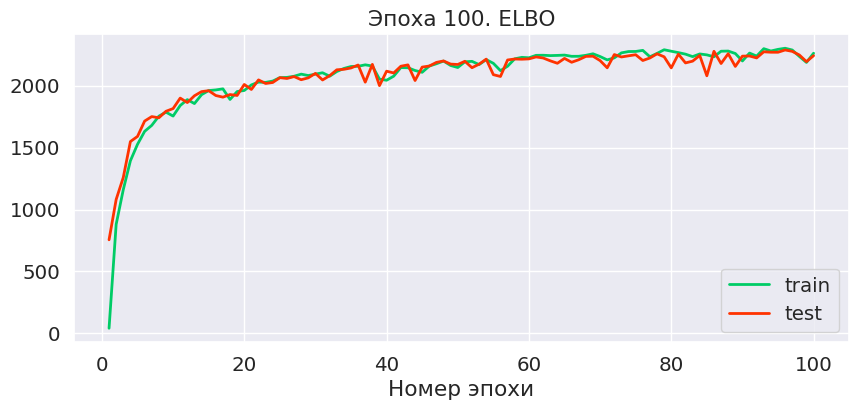

In [11]:
vae_model = VAE(y_dim=2, p=0.1, use_cuda=USE_CUDA)
vae_model.to(DEVICE)
vae_model.fit(train_loader, test_loader, epochs=101, lr=5e-4)

In [12]:
ae_model = AE(y_dim=2, p=0, use_cuda=USE_CUDA)
ae_model.to(DEVICE)
ae_model.fit(train_loader, test_loader, epochs=101, lr=5e-4);

  0%|          | 0/101 [00:00<?, ?it/s]

AttributeError: 'tuple' object has no attribute 'size'

In [ ]:
X_train = train_loader.dataset.data.numpy().astype(np.float32) / 255.0
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = test_loader.dataset.data.numpy().astype(np.float32) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1)

pca = PCA(n_components=2).fit(X_train)

*Для каждого датасета далее произведите следующие сравнения.*
* Визуализируйте гистограммы значений в скрытом пространстве (на скрытом слое). *Если диапазон принимаемых значений достаточно мал, то сеть скорее всего не обучилась.*
* Возьмите сетку значений в скрытом пространстве и визуализируйте ее отображение в исходное пространство посредством декодера (в случае PCA &mdash; линейным преобразованием).
* Возьмите несколько (не более 10) равномерно удаленных точек в скрытом пространстве, с помощью декодера модели VAE получите соответствующие им распределения в исходном пространстве. Визуализируйте эти распредения с помощью эллипса. 
* Сгенерируйте выборку размера 1000 в скрытом пространстве из распределения $\mathcal{N}(0, 1)$ и визуализируйте ее отображение в исходное пространство посредством декодера (в случае PCA &mdash; линейным преобразованием). Насколько распределение ее образа похоже на распределение исходной выборки?

### 1. Визуализируйте гистограммы значений в скрытом пространстве

In [ ]:
vae_values  = []
for x, _ in test_loader:
    y_loc, y_scale = vae_model.encoder(x.to("cpu"))
    tmp = np.random.normal(loc=y_loc.detach().numpy(), scale=y_scale.detach().numpy())
    vae_values.extend(tmp)
vae_values = np.array(vae_values)

In [ ]:
vae_values = []

for x, _ in test_loader:
    y_loc, y_scale = vae_model.encoder(x)
    tmp = np.random.normal(
        loc=y_loc.detach().cpu().numpy(), scale=y_scale.detach().cpu().numpy()
    )
    vae_values.append(tmp)

vae_values = np.vstack(vae_values)

In [ ]:
ae_values = []

for x, _ in test_loader:

    latent_vals = ae_model.encoder(x)
    latent_vals = latent_vals.detach().cpu().numpy()
    ae_values.append(latent_vals)

ae_values = np.vstack(ae_values)


In [ ]:
pca_values = pca.transform(X_test)

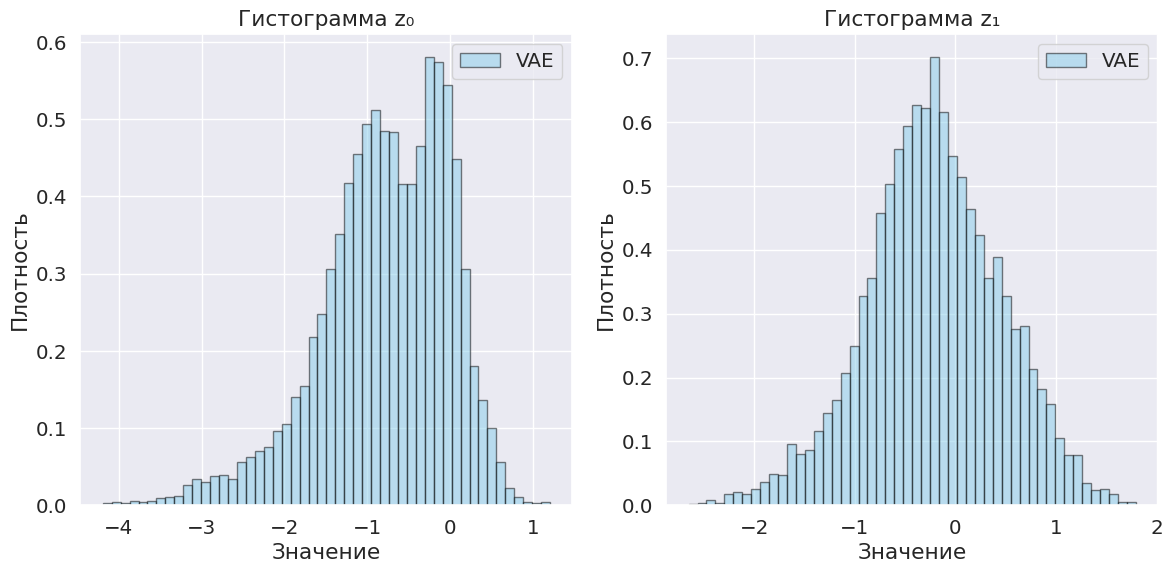

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
alpha = 0.5

# z0
axes[0].hist(vae_values[:, 0], bins=50, alpha=alpha, color='skyblue', edgecolor='black', label='VAE', density=True)
axes[0].hist(ae_values[:, 0], bins=50, alpha=alpha, color='salmon', edgecolor='black', label='AE', density=True)
axes[0].hist(pca_values[:, 0], bins=50, alpha=alpha, color='green', edgecolor='black', label='PCA', density=True)
axes[0].set_title('Гистограмма z₀')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Плотность')
axes[0].legend()

# z1
axes[1].hist(vae_values[:, 1], bins=50, alpha=alpha, color='skyblue', edgecolor='black', label='VAE', density=True)
axes[1].hist(ae_values[:, 1], bins=50, alpha=alpha, color='salmon', edgecolor='black', label='AE', density=True)
axes[1].hist(pca_values[:, 1], bins=50, alpha=alpha, color='green', edgecolor='black', label='PCA', density=True)
axes[1].set_title('Гистограмма z₁')
axes[1].set_xlabel('Значение')
axes[1].set_ylabel('Плотность')
axes[1].legend()

plt.tight_layout()
plt.show()

Как видим, компоненты стянулись к стандартному нормальному, остальные же получились более широкими.

### 2. Возьмите сетку значений в скрытом пространстве и визуализируйте ее отображение в исходное пространство посредством декодера (в случае PCA &mdash; линейным преобразованием).

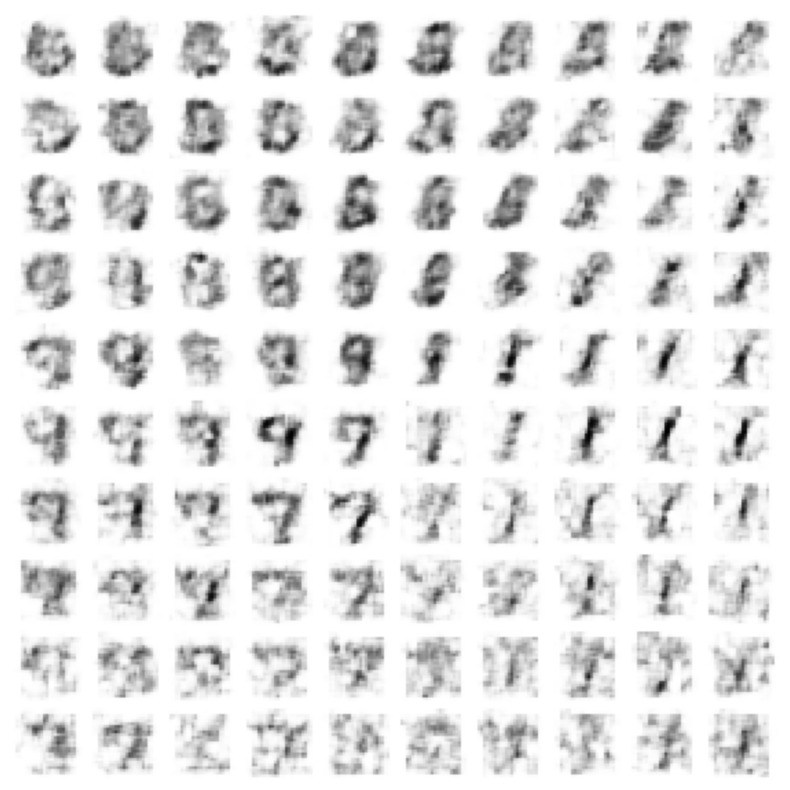

In [ ]:
X1 = np.linspace(-3, 3, 10)
X2 = np.linspace(-3, 3, 10)

figure = np.zeros((28 * 10, 28 * 10))

for i, x1 in enumerate(X1):
    for j, x2 in enumerate(X2):
        z = torch.tensor([[x1, x2]], dtype=torch.float32)
        img = vae_model.decoder(z, return_cpu=True).detach().numpy()
        digit = img[0, 0]
        figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray_r')
plt.axis('off')
plt.show()

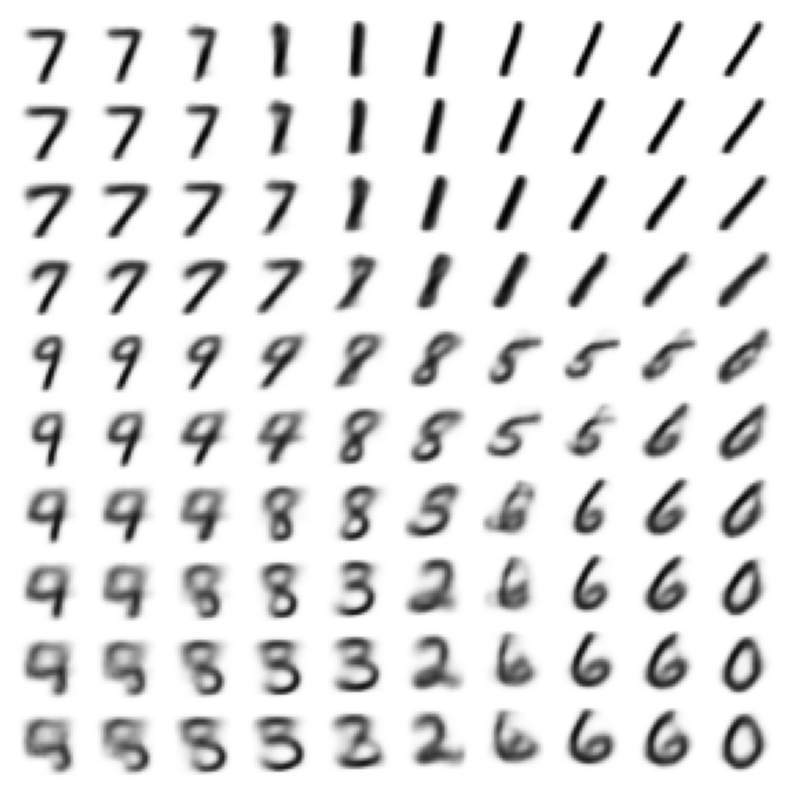

In [ ]:
X1 = np.linspace(-3, 3, 10)
X2 = np.linspace(-3, 3, 10)

figure = np.zeros((28 * 10, 28 * 10))

for i, x1 in enumerate(X1):
    for j, x2 in enumerate(X2):
        z = torch.tensor([[x1, x2]], dtype=torch.float32)
        img = ae_model.decoder(z, return_cpu=True).detach().numpy()
        digit = img[0, 0]
        figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray_r')
plt.axis('off')
plt.show()

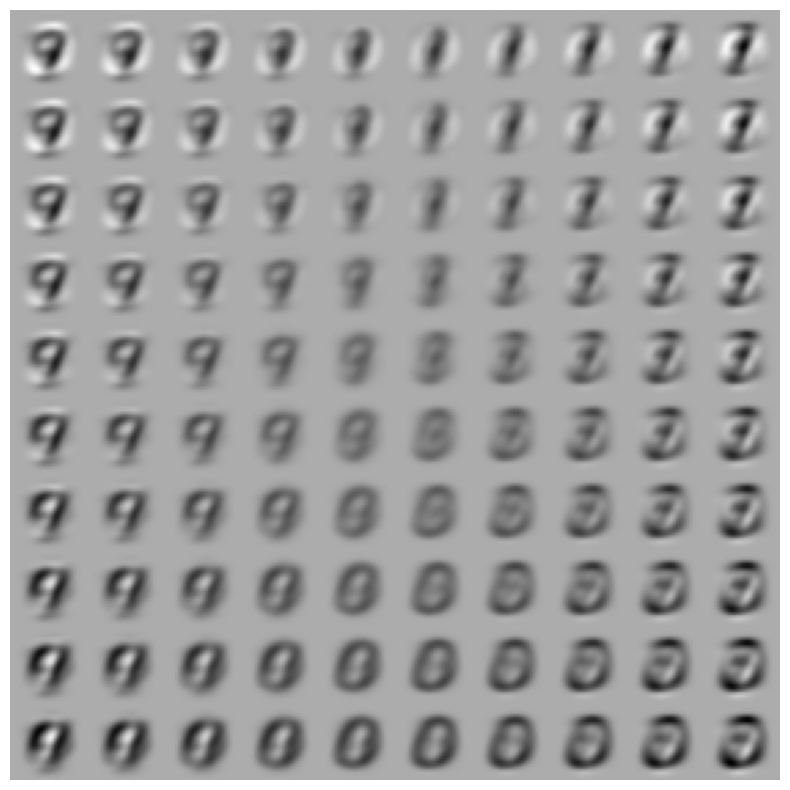

In [ ]:
X1 = np.linspace(-5, 5, 10)
X2 = np.linspace(-5, 5, 10)

figure = np.zeros((28 * 10, 28 * 10))

for i, x1 in enumerate(X1):
    for j, x2 in enumerate(X2):
        z = np.array([[x1, x2]])
        img = pca.inverse_transform(z).reshape(28, 28)
        figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = img

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray_r')
plt.axis('off')
plt.show()

### 4. Возьмите несколько (не более 10) равномерно удаленных точек в скрытом пространстве, с помощью декодера модели VAE получите соответствующие им распределения в исходном пространстве. Визуализируйте эти распредения с помощью эллипса.

In [ ]:
coords = np.linspace(-1, 1, 5)
latent_dots = [
    torch.tensor([x, y], dtype=torch.float32) for x, y in zip(coords, coords)
]
latent_dots = [
    torch.tensor([[x, y]], dtype=torch.float32) for x, y in zip(coords, coords)
]

In [ ]:
decoded_imgs = []
for dot in latent_dots:
    decoded_val = vae_model.decoder(dot).detach().cpu().numpy()  # (1, 1, 28, 28)
    decoded_imgs.append(decoded_val[0, 0])
print(decoded_imgs)

*Эллипс можно простроить следующим образом.*

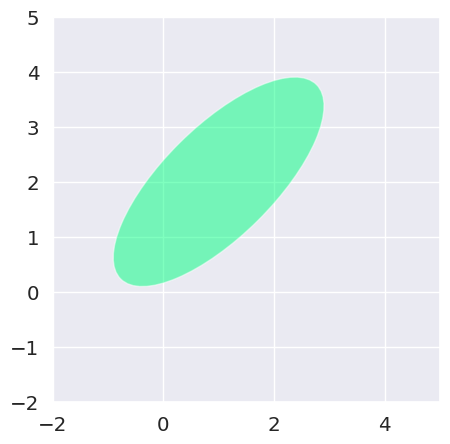

In [ ]:
from matplotlib.patches import Ellipse

ellipse = Ellipse(
    xy=[1, 2],  # Положение центра
    width=5, height=2,  # Параметры формы
    angle=45  # Поворот
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.add_artist(ellipse)
ellipse.set_clip_box(ax.bbox)
ellipse.set_alpha(0.5)  # Прозрачность
ellipse.set_facecolor([0, 1, 0.5])  # Цвет
plt.xlim((-2, 5))
plt.ylim((-2, 5));

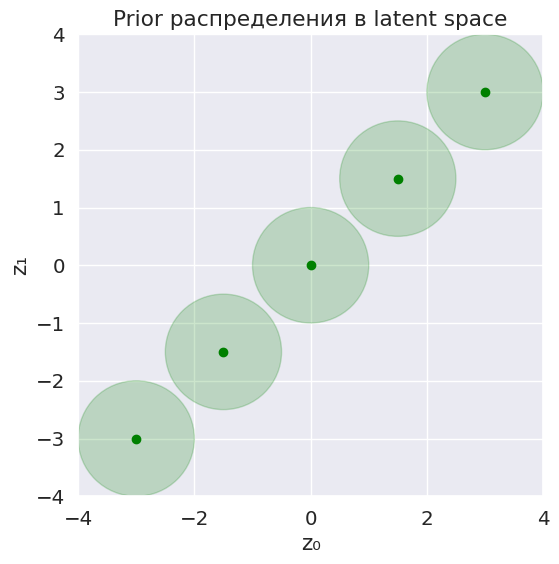

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
coords = np.linspace(-3, 3, 5)
for x, y in zip(coords, coords):
    ellipse = Ellipse(xy=(x, y), width=2, height=2, edgecolor='g',
                      angle=0, facecolor='green', alpha=0.2)
    ax.add_patch(ellipse)
    ax.scatter(x, y, color='green')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel('z₀')
plt.ylabel('z₁')
plt.title('Prior распределения в latent space')
plt.grid(True)
plt.show()

**1.** Рассмотрите те данные, с которыми вы работали в предыдущем домашнем задании про вероятностый PCA. Обучите на этих данных VAE и сравните с вероятностным PCA.

**2.** Повторите те же действия со следующими данными.

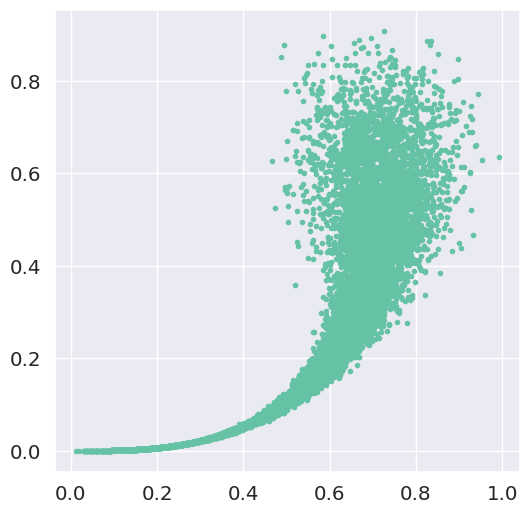

In [ ]:
n = 10000

y = dist.Uniform(0, 1).rsample([n, 1])
r = torch.sqrt(y)
phi = 0.8 * y
data = torch.cat([
    r*torch.cos(phi) + dist.Normal(loc=0, scale=0.1*y**2).rsample(), 
    r*torch.sin(phi) + dist.Normal(loc=0, scale=0.1*y**2).rsample()
], 1)

plt.figure(figsize=(6, 6))
plt.plot(data[:,0], data[:,1], '.');

**3.** Выберите 5\% случайных точек и зашумите их с помощью шума из распределения Коши, параметр масштаба распределения Коши возьмите равным 0.01. Обучите на этих данных VAE. Насколько хорошие получились результаты?

Замените в VAE распределение данных $X$ на распределение Стьюдента, установив число степеней свободы в качестве гиперпараметра. Обучите полученную модель.

Сделайте выводы по задаче.

---
### Задача 2.

Эта задача призвана проиллюстрировать на простом примере принцип работы условного вариационного автоэнкодера (CVAE) и сравнить его с обычным вариационным автоэнкодером (VAE).

Повторите эксперимент из задачи 1 со следующими данными:

/home/udeneev-av/tmp/ipykernel_2136034/2829567082.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  -np.exp(-x+2) + 3*x - 2


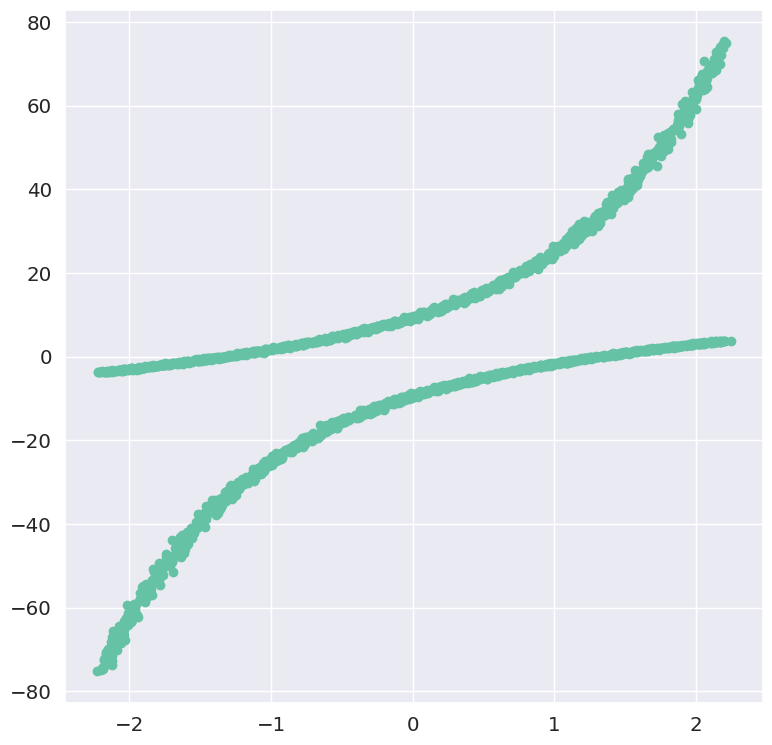

In [ ]:
n = 2000

# Данные
x = torch.linspace(-2.2, 2.2, n//2).view((-1, 1))
data1 = torch.cat([
    x, 
    torch.exp(x+2) + 3*x + 2
], 1)
data2 = torch.cat([
    x, 
    -np.exp(-x+2) + 3*x - 2
], 1)

data = torch.cat([data1, data2])
data += dist.Normal(loc=0, scale=0.03).rsample(data.shape)

# Метки
labels = torch.zeros(n).view((-1, 1))
labels[n//2:] = 1

# Визуализация
plt.figure(figsize=(9, 9))
plt.scatter(data[:, 0], data[:, 1]);

Теперь обучите на этих данных CVAE, передавая в качестве метки номер кривой. Проинтерпретируйте результаты.

---
### Задача 3. 

Использовать готовые инструменты это хорошо, но не всегда возможно в силу различных технических ограничений, как связанными с техническими требованиями заказчика, так и возможностями самих инструментов.

Предлагаем вам потренироваться в реализации чистого VAE с помощью чистого `pytorch` без использования `pyro`. Для этого вы можете взять заготовки нейросетей с занятия и реализовать процесс обучения, оптимизируя ELBO с помощью двойной стохастичности, что мы расписали на занятии.

Примените вашу реализацию к датасету Fashion MNIST подобно тому, как мы делали на занятии. Сравните ее с реализацией через `pyro` по следующим характеристикам:
* скорость сходимости;
* время работы;
* трудоемкость при реализации.

Насколько было бы просто обходиться без `pyro` в случае более сложных распределений и зависимостей?

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока